# Analyse von Wasserverbrauchswerten (Monatsdaten)

Dieses Notebook dient der **Einlesung, Bereinigung, Analyse und Visualisierung** von Wasserverbrauchsdaten (z. B. pro Monat).

**Ziele**
- Excel-Daten robust einlesen (inkl. hilfreicher Fehlermeldung)
- Numerische Spalten erkennen & beschreibende Kennzahlen berechnen
- Zeitliche Verläufe visualisieren (Linien- und Balkendiagramme)
- Auffälligkeiten/Spitzen identifizieren (z. B. Ausreißer)
- 95% - Konfidenzintervalle berechnen und visualisieren

> **Hinweis:** Passe den Dateipfad unter `EXCEL_PATH` an deine lokale Struktur an.


## 1) Setup & Bibliotheken

Bibliotheken verwendet:
- **pandas** zur Datenmanipulation
- **numpy** für Berechnungen mit mehrdimensionalen Arrays und mathematischen Operationen
- **scipy.stats** für statistische Tests und statistische Auswertungen
- **matplotlib** für Plots
- **seaborn (optional)** für schönere Standardplots

Wenn `seaborn` in deiner Umgebung fehlt, kannst du es direkt aus dem Notebook installieren:
```python
import sys
!"{sys.executable}" -m pip install seaborn
```


In [58]:
# Bibliotheken laden
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
%matplotlib inline

# seaborn ist optional – wir versuchen es zu importieren
try:
    import seaborn as sns
    _HAS_SEABORN = True
except ModuleNotFoundError:
    _HAS_SEABORN = False
    print("Hinweis: seaborn ist nicht verfügbar. Plots laufen trotzdem mit matplotlib.")

plt.rcParams["figure.figsize"] = (10, 4)


## 2) Daten einlesen

Erwartet wird eine Excel-Datei, z. B. mit einer Spalte **`Monat`** und mindestens einer numerischen Verbrauchsspalte (z. B. `Verbrauch`, `m³`, `Liter`, …).

- Falls `Monat` als Text vorliegt (z. B. `2025-01`), wird es in ein Datum konvertiert.
- Numerische Spalten werden automatisch erkannt.

    > Die Daten werden bewusst als Excel-Datei und nicht als csv-Datei eingelesen.


In [59]:
from pathlib import Path

# Pfad zur Excel-Datei (ggf. anpassen)
EXCEL_PATH = Path("../data/raw/Wasserverbrauchswerte.xlsx")

if not EXCEL_PATH.exists():
    raise FileNotFoundError(
        f"Datei nicht gefunden: {EXCEL_PATH.resolve()}\n"
        "Prüfe den Pfad oder lege die Datei im Ordner 'data/' ab."
    )

# Excel-Datei einlesen
daten = pd.read_excel(EXCEL_PATH, engine="openpyxl")

print("Spalten:", list(daten.columns))
print("\nDatentypen:\n", daten.dtypes)
print("\nVorschau:")
display(daten.head())


Spalten: ['Monat', 2022, 2023, 2024]

Datentypen:
 Monat     object
2022     float64
2023     float64
2024     float64
dtype: object

Vorschau:


,Monat,2022,2023,2024
0,Januar,33.9,32.4,27.9
1,Februar,35.1,32.2,23.6
2,März,35.0,33.4,31.8
3,April,41.3,28.7,26.8
4,Mai,42.9,30.0,29.8


## 3) Bereinigung & Vorbereitung

Schritte:
1. `Monat` (falls vorhanden) als Datum interpretieren und als Index setzen
2. Nur numerische Spalten als Messwerte nutzen
3. Fehlende Werte (NaN) transparent machen

> Falls eine Datenspalte anders heißt als `Monat`, passe den Namen unten an.


In [60]:
df = daten.copy()

# 1) Monat sauber als Index setzen (ohne NaT-Problem)
if "Monat" in df.columns:
    # Falls Monat bereits Datumsformat ist → behalten
    if np.issubdtype(df["Monat"].dtype, np.datetime64):
        df = df.sort_values("Monat").set_index("Monat")

    else:
        # Monat ist Text (Jan, Feb, 01.2022 etc.)
        # -> NICHT zu datetime zwingen
        df["Monat"] = df["Monat"].astype(str).str.strip()
        df = df.set_index("Monat")

else:
    print("Hinweis: Keine Spalte 'Monat' gefunden – Index bleibt unverändert.")


# 2) Numerische Spalten sicher erkennen
# Excel-Fall: Zahlen sind als Text mit Komma gespeichert
for c in df.columns:
    s = df[c].astype(str).str.strip()

    # falls Wert Komma-Dezimal hat (z.B. "33,9"), dann umwandeln
    has_comma_decimal = s.str.contains(",", na=False)

    s = s.where(~has_comma_decimal, s.str.replace(".", "", regex=False))  # Tausenderpunkt weg
    s = s.where(~has_comma_decimal, s.str.replace(",", ".", regex=False)) # Komma -> Punkt

    df[c] = pd.to_numeric(s, errors="coerce")

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if not num_cols:
    raise ValueError(
        "Keine numerischen Spalten gefunden. "
        "Prüfe, ob Verbrauchswerte als Zahlen eingelesen wurden."
    )

print("Numerische Spalten:", num_cols)


# 3) Fehlende Werte prüfen
missing = df[num_cols].isna().sum()
print("\nFehlende Werte pro Spalte:\n", missing)

display(df.head())


Numerische Spalten: [2022, 2023, 2024]

Fehlende Werte pro Spalte:
 2022    0
2023    0
2024    0
dtype: int64


,2022,2023,2024
Monat,,,
Januar,33.9,32.4,27.9
Februar,35.1,32.2,23.6
März,35.0,33.4,31.8
April,41.3,28.7,26.8
Mai,42.9,30.0,29.8


## 4) Deskriptive Statistik

Berechnet werden pro numerischer Spalte:
- Mittelwert, Median, Minimum, Maximum
- Standardabweichung
- Quartile (25 %, 50 %, 75 %)

Zusätzlich wird ein kurzer Überblick via `describe()` ausgegeben.


In [61]:
summary = pd.DataFrame({
    "mean": df[num_cols].mean(),
    "median": df[num_cols].median(),
    "min": df[num_cols].min(),
    "max": df[num_cols].max(),
    "std": df[num_cols].std(),
}).round(3)

display(summary)

print("\nDescribe():")
display(df[num_cols].describe().round(3))


,mean,median,min,max,std
2022,35.750,34.95,31.8,42.9,3.295
2023,28.583,27.90,24.2,33.4,3.574
2024,27.525,27.85,18.9,31.8,3.714



Describe():


,2022,2023,2024
count,12.000,12.000,12.000
mean,35.750,28.583,27.525
std,3.295,3.574,3.714
min,31.800,24.200,18.900
25%,33.800,25.375,25.925
50%,34.950,27.900,27.850
75%,36.075,32.250,30.125
max,42.900,33.400,31.800


## 5) Visualisierung: Zeitliche Verläufe

- Linienplot pro numerischer Spalte
- Rolling Mean (gleitender Mittelwert), um Trends zu glätten


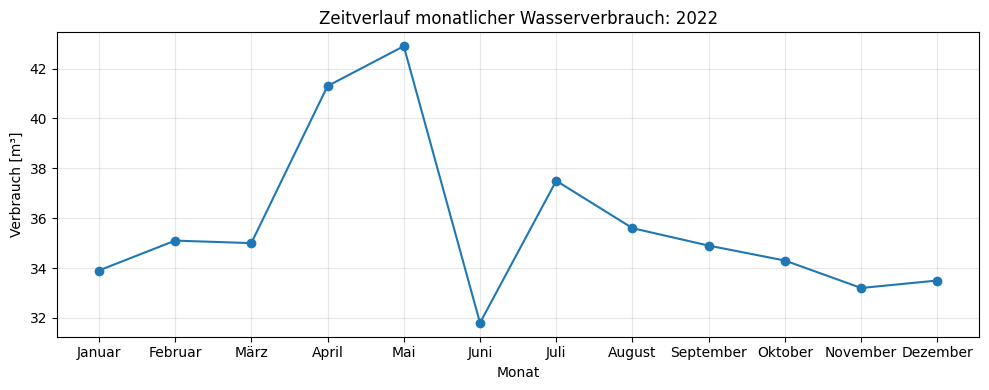

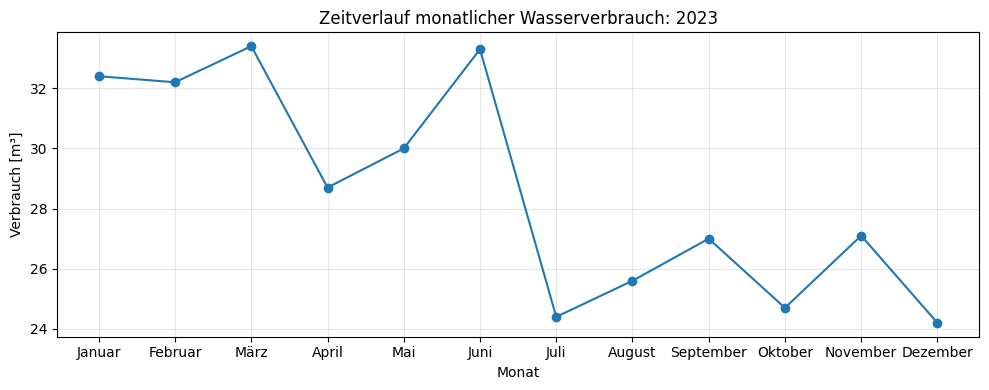

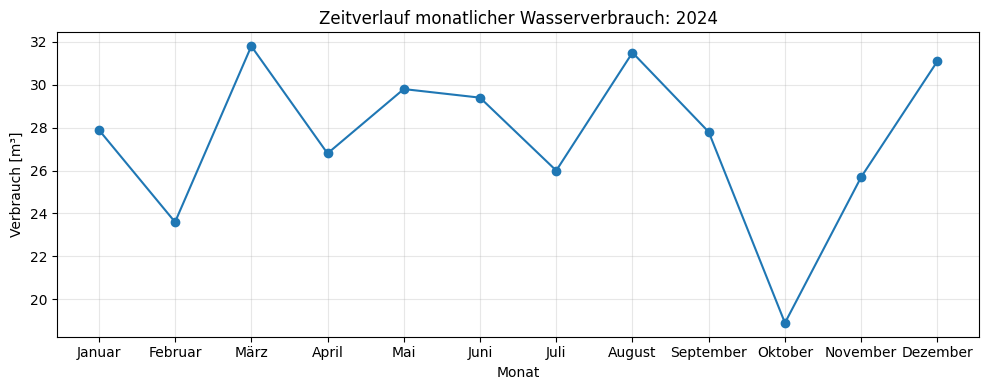

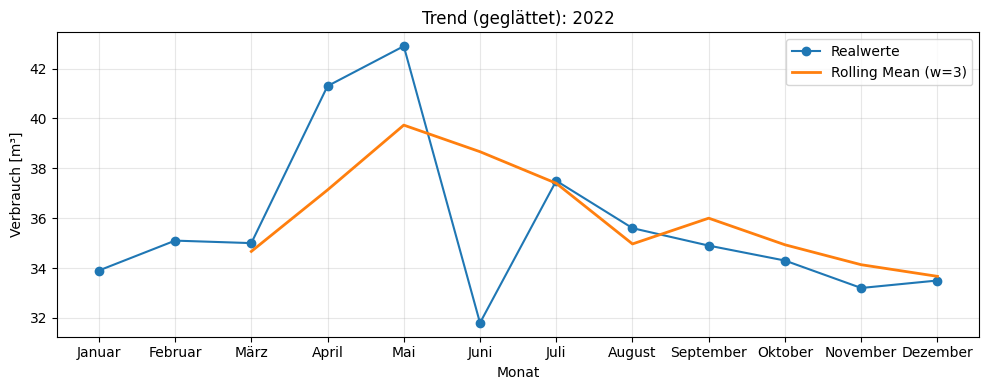

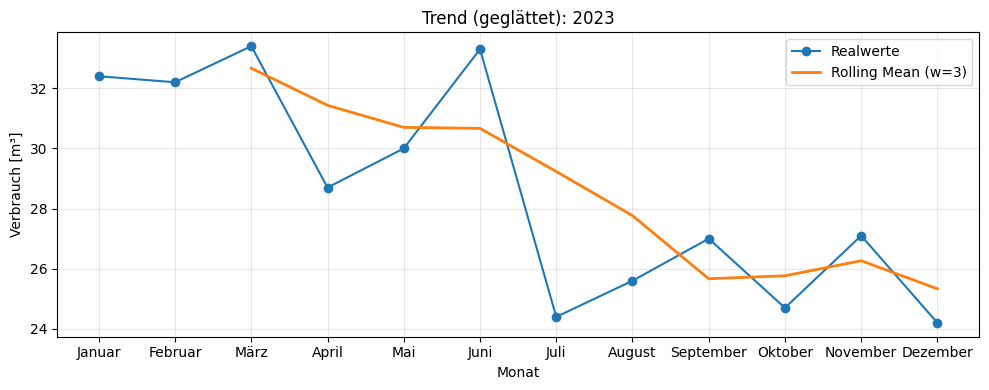

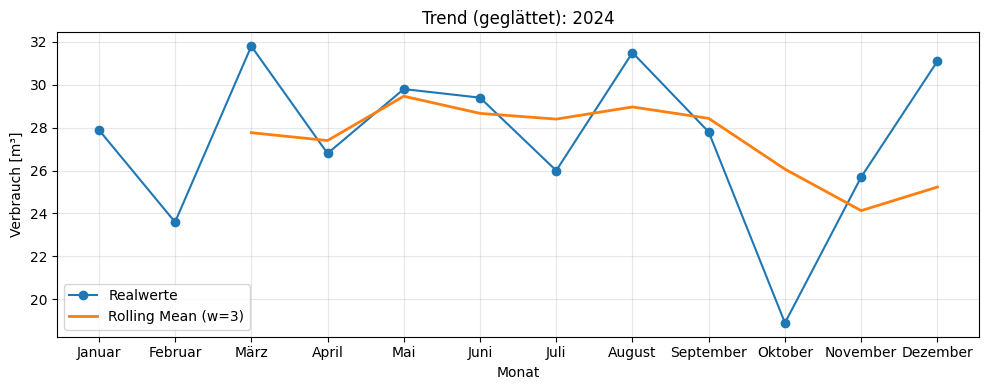

In [62]:
# Linienplots
for col in num_cols:
    plt.figure()
    plt.plot(df.index, df[col], marker="o")
    plt.title(f"Zeitverlauf monatlicher Wasserverbrauch: {col}")
    plt.xlabel("Monat" if "Monat" in daten.columns else "Index")
    plt.ylabel("Verbrauch [m³]")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Trendglättung (3er Rolling Mean), wenn genügend Punkte vorhanden
if len(df) >= 6:
    window = 3
    for col in num_cols:
        plt.figure()
        plt.plot(df.index, df[col], marker="o", label="Realwerte")
        plt.plot(df.index, df[col].rolling(window).mean(), linewidth=2, label=f"Rolling Mean (w={window})")
        plt.title(f"Trend (geglättet): {col}")
        plt.xlabel("Monat" if "Monat" in daten.columns else "Index")
        plt.ylabel("Verbrauch [m³]")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


## 6) Auffälligkeiten / Spitzenwerte

Hier werden die größten Werte pro Spalte identifiziert und im Plot markiert.



Top-3 für 2022:


Monat
Mai      42.9
April    41.3
Juli     37.5
Name: 2022, dtype: float64

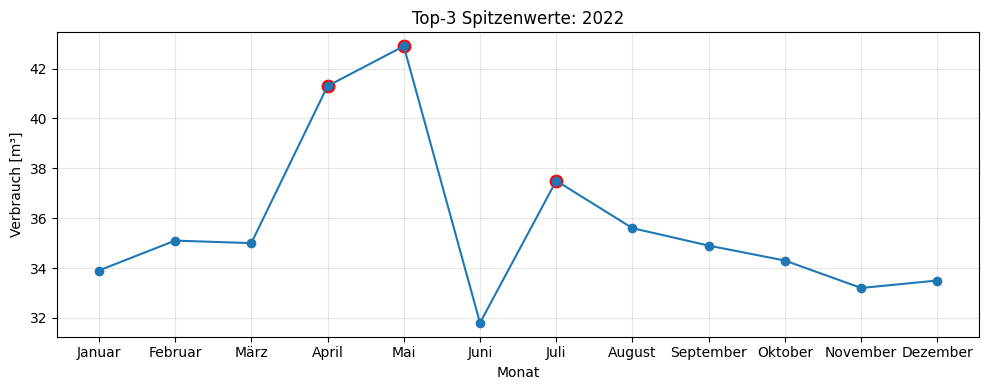


Top-3 für 2023:


Monat
März      33.4
Juni      33.3
Januar    32.4
Name: 2023, dtype: float64

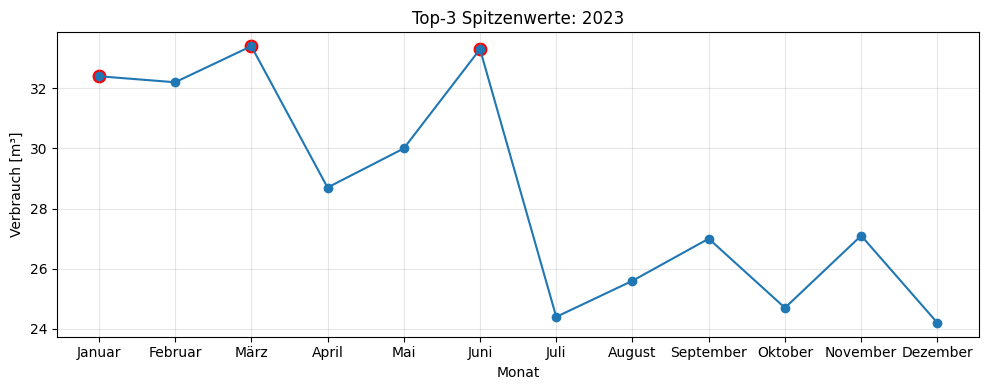


Top-3 für 2024:


Monat
März        31.8
August      31.5
Dezember    31.1
Name: 2024, dtype: float64

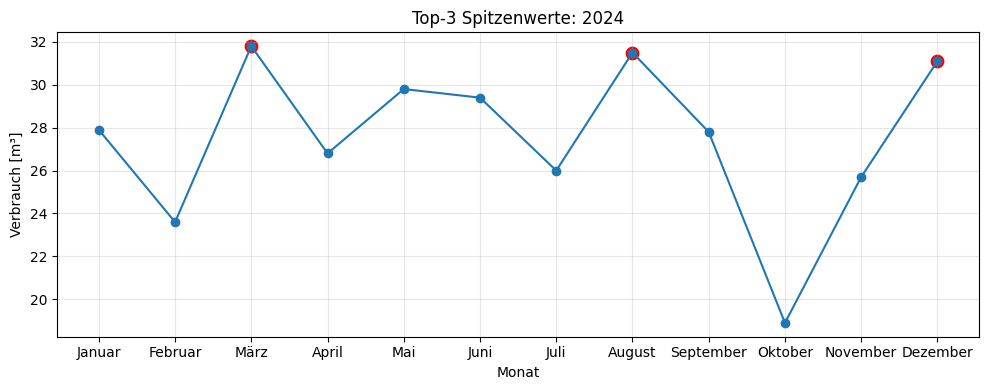

In [63]:
top_k = 3

for col in num_cols:
    s = df[col].dropna()
    top = s.nlargest(top_k)
    print(f"\nTop-{top_k} für {col}:")
    display(top)

    plt.figure()
    plt.plot(df.index, df[col], marker="o")
    plt.scatter(top.index, top.values, s=80, c="red")
    plt.title(f"Top-{top_k} Spitzenwerte: {col}")
    plt.xlabel("Monat" if "Monat" in daten.columns else "Index")
    plt.ylabel("Verbrauch [m³]")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 7) Verteilung & Ausreißeranalyse (Boxplot / Histogramm)

Boxplots visualisieren Ausreißer, Histogramme eignen sich für Verteilungen.


In [64]:
for col in num_cols:
    s = df[col].dropna()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr

    out = s[(s < lower) | (s > upper)]

    print(f"Ausreißer {col}:")
    display(out)


Ausreißer 2022:


Monat
April    41.3
Mai      42.9
Name: 2022, dtype: float64

Ausreißer 2023:


Series([], Name: 2023, dtype: float64)

Ausreißer 2024:


Monat
Oktober    18.9
Name: 2024, dtype: float64

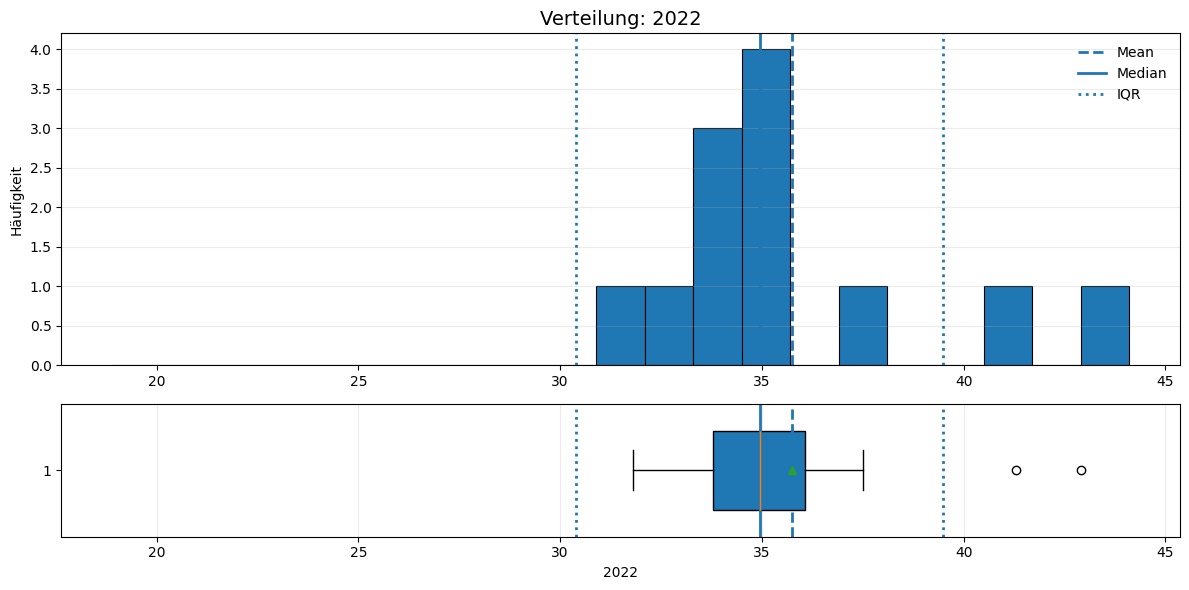

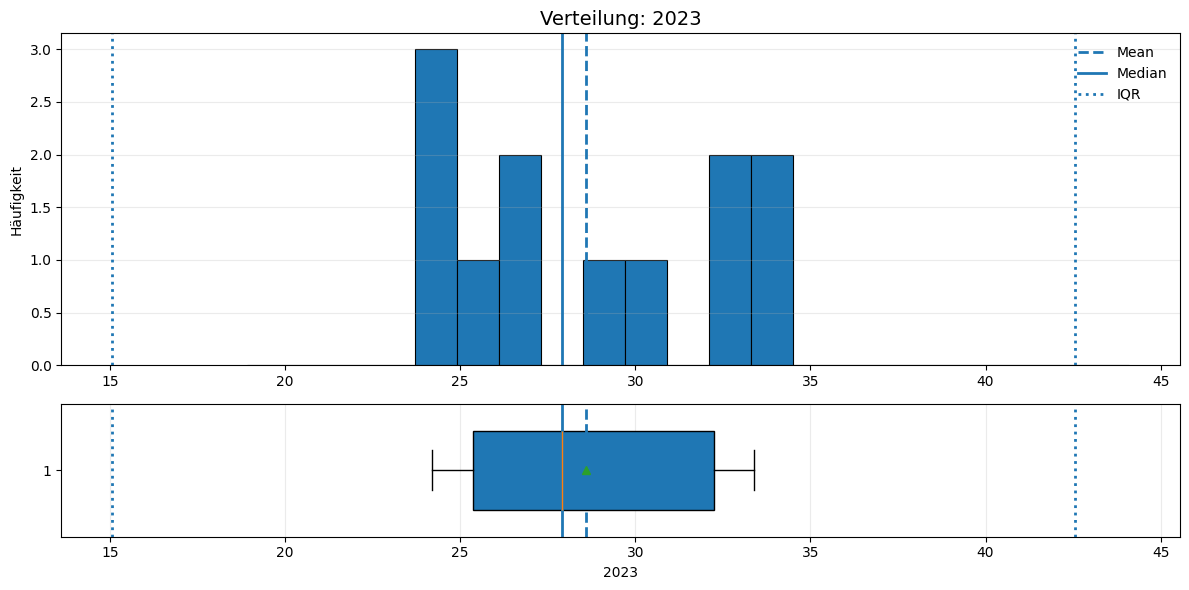

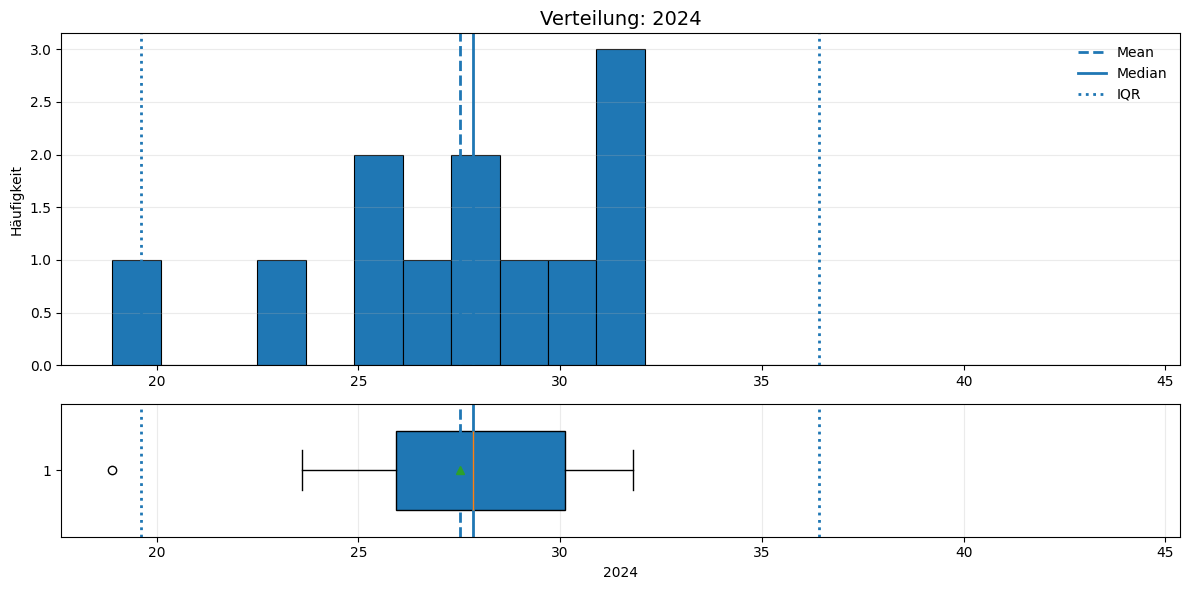

In [65]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("default")


# GLOBAL gleiche Bins für ALLE Jahre
global_min = df[num_cols].min().min()
global_max = df[num_cols].max().max()

bin_width = (global_max - global_min) / 20
bins = np.arange(global_min, global_max + bin_width, bin_width)

for col in num_cols:
    s = df[col].dropna()

    mean_val = s.mean()
    median_val = s.median()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    fig, axes = plt.subplots(
        2, 1,
        figsize=(12,6),
        gridspec_kw={"height_ratios":[3,1.2]}
    )

    # Histogramm
    ax = axes[0]
    ax.hist(s, bins=bins, edgecolor="black", linewidth=0.8)

    ax.axvline(mean_val, linestyle="--", linewidth=2, label="Mean")
    ax.axvline(median_val, linestyle="-", linewidth=2, label="Median")
    ax.axvline(lower, linestyle=":", linewidth=2, label="IQR")
    ax.axvline(upper, linestyle=":", linewidth=2)

    ax.set_title(f"Verteilung: {col}", fontsize=14)
    ax.set_ylabel("Häufigkeit")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False)

    # Boxplot
    ax = axes[1]
    ax.boxplot(s, vert=False, widths=0.6, patch_artist=True, showmeans=True)

    ax.axvline(mean_val, linestyle="--", linewidth=2)
    ax.axvline(median_val, linestyle="-", linewidth=2)
    ax.axvline(lower, linestyle=":", linewidth=2)
    ax.axvline(upper, linestyle=":", linewidth=2)

    ax.set_xlabel(col)
    ax.grid(axis="x", alpha=0.25)
    axes[1].set_xlim(axes[0].get_xlim())

    plt.tight_layout()
    plt.show()


## 8) Anomalie-Detection

Werte außerhalb von [Q1−1.5⋅IQR, Q3+1.5⋅IQR] gelten als auffällig.

In [66]:
anomalies_iqr = []

for col in num_cols:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    out = df[(df[col] < lower) | (df[col] > upper)][[col]].copy()
    out["method"] = "IQR"
    out["lower"] = lower
    out["upper"] = upper
    anomalies_iqr.append(out)

anomalies_iqr_df = pd.concat(anomalies_iqr)
anomalies_iqr_df = anomalies_iqr_df[
    ["method", "lower", "upper"]
    + [c for c in anomalies_iqr_df.columns if c not in ["method", "lower", "upper"]]
]

display(anomalies_iqr_df)


,method,lower,upper,2022,2023,2024
Monat,,,,,,
April,IQR,30.3875,39.4875,41.3,NaN,NaN
Mai,IQR,30.3875,39.4875,42.9,NaN,NaN
Oktober,IQR,19.6250,36.4250,NaN,NaN,18.9


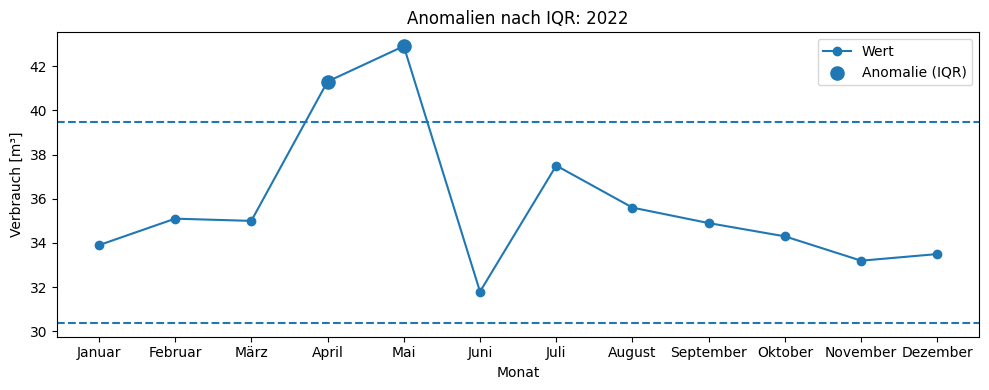

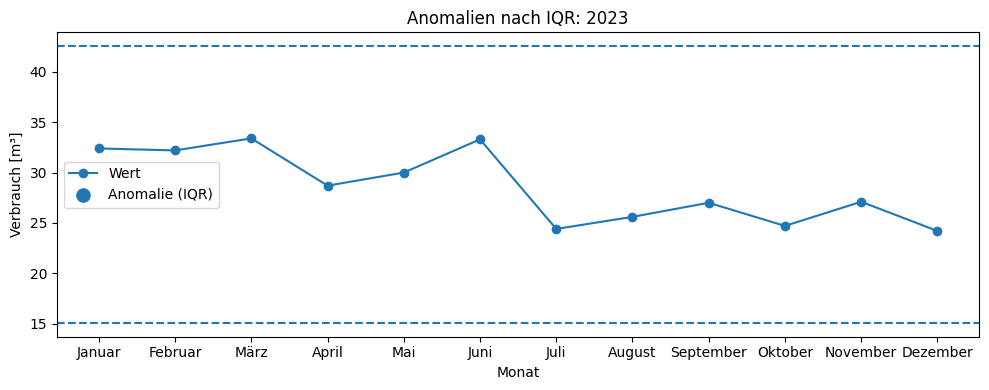

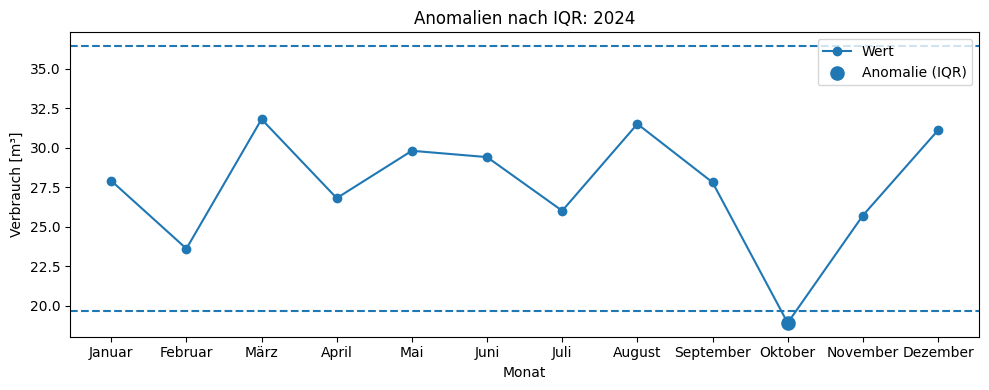

In [67]:
for col in num_cols:
    s = df[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr

    mask = (s < lower) | (s > upper)

    plt.figure(figsize=(10,4))
    plt.plot(df.index, s, marker="o", label="Wert")
    plt.scatter(df.index[mask], s[mask], s=90, label="Anomalie (IQR)")
    plt.axhline(lower, linestyle="--")
    plt.axhline(upper, linestyle="--")
    plt.title(f"Anomalien nach IQR: {col}")
    plt.xlabel("Monat")
    plt.ylabel("Verbrauch [m³]")

    plt.legend()
    plt.tight_layout()
    plt.show()


## 9) Zusammenhang zwischen Variablen

Falls es mehrere numerische Spalten gibt, wird der Korrelationskoeffizient zwischen den Variablen berechnet und mithilfe einer Heatmap visualisiert.


,2022,2023,2024
2022,1.000,-0.055,0.068
2023,-0.055,1.000,0.236
2024,0.068,0.236,1.000


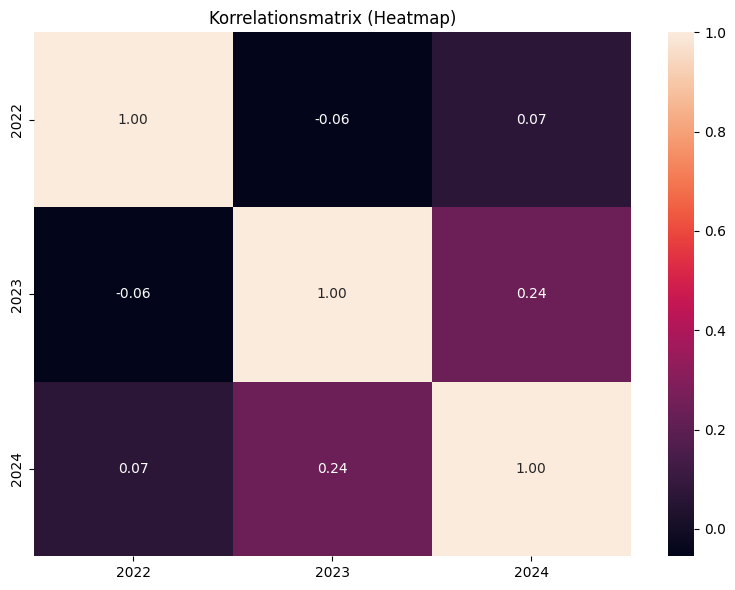

In [68]:
if len(num_cols) >= 2:
    corr = df[num_cols].corr()
    display(corr.round(3))

    if _HAS_SEABORN:
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr, annot=True, fmt=".2f")
        plt.title("Korrelationsmatrix (Heatmap)")
        plt.tight_layout()
        plt.show()
else:
    print("Nur eine numerische Spalte vorhanden – Korrelationen sind nicht sinnvoll.")


## 10) 95% Konfidenzintervalle
Schätzung der Unsicherheit des Mittelwerts.

In [69]:
ci_results = []

for col in num_cols:
    data = df[col].dropna()
    n = len(data)
    mean = data.mean()
    std = data.std(ddof=1)

    t = stats.t.ppf(0.975, n-1)
    margin = t * std / np.sqrt(n)

    ci_results.append([col, mean, mean-margin, mean+margin])

ci_df = pd.DataFrame(ci_results,
                     columns=["Jahr","Mittelwert","CI_low","CI_high"])

display(ci_df)

,Jahr,Mittelwert,CI_low,CI_high
0,2022,35.750000,33.656608,37.843392
1,2023,28.583333,26.312454,30.854213
2,2024,27.525000,25.165153,29.884847


## 11) Konfidenzintervalle visualisieren

Rolling Mean mit w=3 (gleitender Mittelwert)

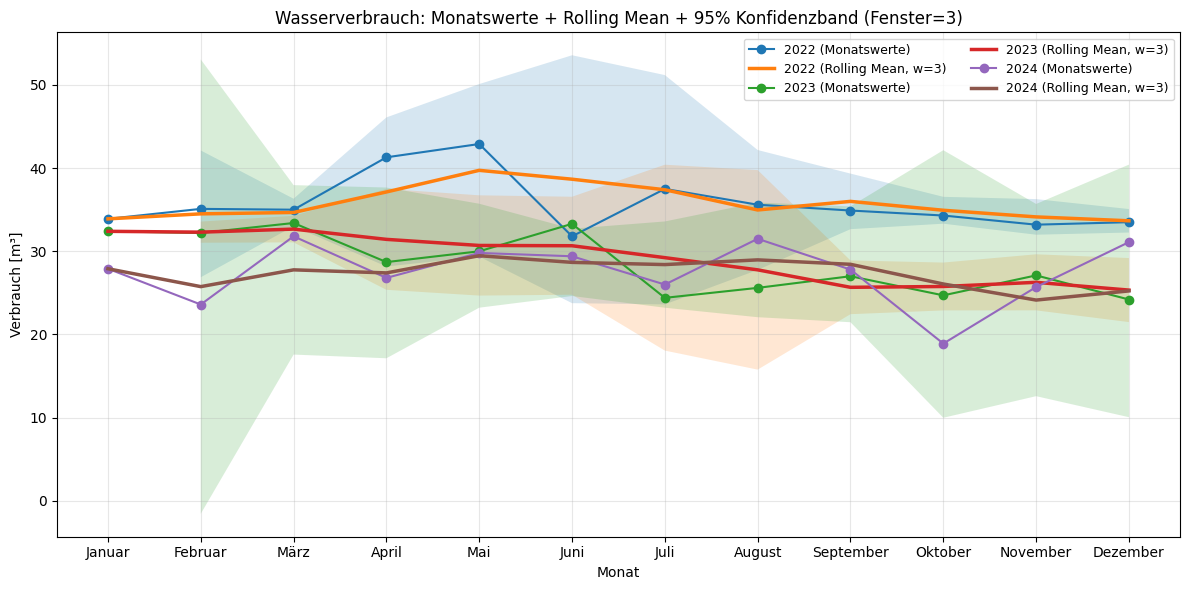

In [70]:
# Einstellungen
window = 3  # 3-Monats-Fenster (didaktisch gut)
alpha = 0.05

plt.figure(figsize=(12, 6))

for col in num_cols:
    y = df[col].astype(float)

    # Rolling-Statistiken
    roll_mean  = y.rolling(window=window, min_periods=1).mean()
    roll_std   = y.rolling(window=window, min_periods=2).std(ddof=1)   # std braucht mind. 2 Werte
    roll_n     = y.rolling(window=window, min_periods=1).count()

    # t-Kritischer Wert je Zeitpunkt (abhängig von n)
    # Für n=1 ist df=0 → t undefiniert; dort setzen wir das Band auf 0 Breite (oder NaN)
    dfree = (roll_n - 1).clip(lower=1)  # mindestens 1, damit ppf definiert ist
    tcrit = pd.Series(stats.t.ppf(1 - alpha/2, dfree), index=y.index)

    # Margin of Error: t * s / sqrt(n)
    margin = tcrit * (roll_std / np.sqrt(roll_n))

    # Plot: Original + Rolling Mean + CI-Band
    plt.plot(df.index, y, marker="o", linewidth=1.5, label=f"{col} (Monatswerte)")
    plt.plot(df.index, roll_mean, linewidth=2.5, label=f"{col} (Rolling Mean, w={window})")
    plt.fill_between(df.index, roll_mean - margin, roll_mean + margin, alpha=0.18)

plt.title(f"Wasserverbrauch: Monatswerte + Rolling Mean + 95% Konfidenzband (Fenster={window})")
plt.xlabel("Monat")
plt.ylabel("Verbrauch [m³]")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

## 12) Fazit

Notiere hier kurz:
- Welche Monate fallen besonders auf?
- Gibt es saisonale Muster?
- Welche nächsten Schritte wären sinnvoll (z. B. Normalisierung pro Haushalt/Person, Wetterdaten, Regression/Forecast)?

**Beispielhafte nächste Schritte:**
- Verbrauch pro Person/Tag berechnen (wenn Personenzahl verfügbar)
- Forecasting (z. B. ETS/SARIMAX/Prophet) bei genügend langen Reihen
